# MAPD Project : Clustering - k-Means ||

## Introduction

In this notebook, we implement the k-means‖ algorithm, following the original paper by Bahmani et al., "Scalable K-Means++" (2012). The standard k-means++ initialization is inherently sequential: it selects one center at a time, each depending on the previous ones which makes it a bottleneck when scaling to large datasets. k-means‖ addresses this by sampling multiple candidate centers in parallel over a small number of rounds, making it suitable for distributed computation.

Our goal is to implement and benchmark this parallelized initialization against a baseline approaches (Random initialization), evaluating both clustering cost and running time. We deploy our implementation on a VM, varying the number of workers and partitions to study its scalability.

The objective of our study is a real-world dataset, KDDCup1999, containing network connection records built for a network intrusion detection challenge. Each record is described by numerical features, and the dataset is large enough (hundreds of thousands to millions of points, depending on the subset used) to be a realistic test for the kind of large-k clustering scenario k-means‖ was designed for, unlike small toy datasets, it lets us actually put the parallel initialization to the test at a scale where a sequential approach like k-means++ starts to struggle.




## Initialization algorithm: k-means||

**The k-means‖ algorithm** can be seen as a natural parallelization of k-means++. It keeps the same core idea: repeatedly sampling new candidate centers proportionally to their squared distance from the centers chosen so far ($D^2$-sampling), which is what gives k-means++ its strong theoretical guarantees, but reworks it so that many candidates can be drawn *at once*, instead of one at a time. In k-means++, each new center depends on all the previous ones, center $i+1$ can't be chosen until center $i$ is fixed, so the whole initialization requires $k$ fully sequential passes over the data.

k-means‖ breaks this dependency by oversampling in batches: in each of $r$ rounds, every point $x$ is sampled independently with probability proportional to $\ell \cdot d(x, C)^2 / \phi_X(C)$, where $\ell$ is an oversampling factor and $\phi_X(C)$ is the current clustering cost. All points sampled in a round are added to the candidate set $C$ together. After $r$ rounds, $C$ holds roughly $O(r\ell)$ points, more than the $k$ we actually need. Each candidate is then weighted by how many original data points are closest to it, and this small weighted set is reduced to exactly $k$ centers via a cheap, local weighted k-means++ pass. 

As a baseline, we also test the simplest possible initialization with **Random initialization**: picking $k$ points uniformly at random from the dataset, with no weighting by distance or iterative refinement at all. It's essentially free to compute, a single pass to sample $k$ indices, which makes it a useful lower bound: any more sophisticated initialization (k-means++, k-means‖) should beat it substantially in clustering cost, at the price of extra computation.




## Experimental Set-up

**Experimental setup.** All experiments run on a small cluster of virtual machines connected via SSH: one head node running the scheduler and up to 8 worker nodes, each with roughly 8 GB of RAM. For each run we can choose how many of these workers are active and into how many partitions the dataset is split, and we use exactly these two parameters (number of workers and number of partitions) to sweep the scalability experiments, keeping everything else (dataset size, algorithm parameters) fixed.

**Parallelization with Dask.** We parallelize the algorithm using Dask: the dataset is split into partitions with `dask.bag`, and each computation step (sampling, distance updates, Lloyd's assignment) is expressed as a `dask.delayed` task that operates independently on a single partition. These tasks are combined into a task graph and executed with `dask.compute`/`dask.persist`, letting Dask schedule and run them across multiple machines rather than a single process. To actually distribute the work, we launch a `dask.distributed` `SSHCluster` spanning several VM nodes and connect to it via a `Client`; by controlling how many worker nodes join the cluster and how many partitions the data is split into, we can systematically benchmark how the algorithm's running time scales with both parameters.

**Da RICONTROLLARE**
**Data loading and preprocessing.** `data_loader.load_dataset` downloads the KDDCup1999 `.gz` once and streams it into `n_partitions` Parquet shard files (never holding the full CSV in memory), caching them for reuse. Each shard is then scattered round-robin to exactly one worker via `client.scatter`, so no single node ever holds the whole dataset. Preprocessing runs in two passes on the workers: the first drops the non-numeric columns (`protocol_type`, `service`, `flag`) and the `label` column, coerces the rest to numeric, drops invalid/NaN rows, and reduces this into global mean/std per feature (and detects constant columns, e.g. `num_outbound_cmds`, std=0); the second pass re-applies the same cleaning to each shard and standardizes it to zero mean and unit variance using those global statistics, before any distance is computed. The result is a `dask.array` with one chunk per shard — the format the rest of the pipeline operates on. Standardizing up front keeps every feature on a comparable scale and noticeably speeds up the distributed distance computations downstream.


## Gaussian mixture

First we start the analysis of the k-means‖ algorithm with a smaller synthetic dataset called GaussMixture, where we sampled $k$ centers from a 15-dimensional spherical Gaussian distribution with mean at the origin and variance $R$. We then added points from Gaussian distributions of unit variance around each center. Given the $k$ centers, this is a mixture of $k$ spherical Gaussians with equal weights. This is a small dataset with $n=10{,}000$ sampled points, so we are able to run it on a single machine and to study it with the sequential implementation of k-means‖.

In the figure below, we plot the cost of the final solution as a function of the number of rounds used to initialize k-means‖ on GaussMixture with $k=50$ for different values of $R\in \{1,10,100\}$.


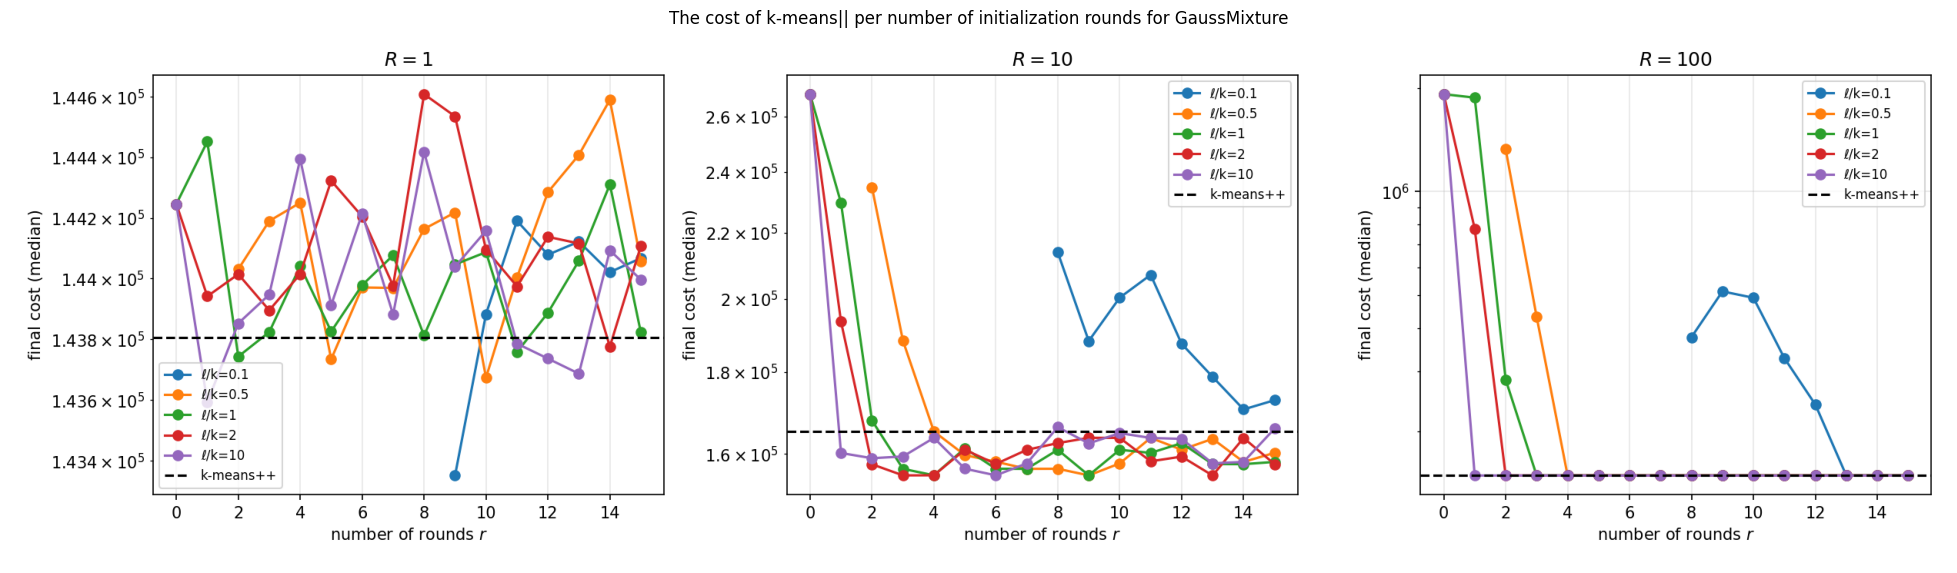

In [1]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

img = mpimg.imread("/home/ubuntu/Project/libero_development/notebooks/figures/fig52_cost_vs_rounds.png")
plt.figure(figsize=(25, 10))
plt.imshow(img)
plt.axis("off")
plt.title("The cost of k-means|| per number of initialization rounds for GaussMixture")
plt.show()


We also plotted the final potential achieved by k-means++ as point of comparison. $R$ is the variance of the Gaussian distribution from which the $k$ cluster centers are drawn (centers ~ $\mathcal{N}(0, R))$ in the GaussMixture synthetic dataset, controlling how well-separated the underlying clusters are: larger $R$ yields more widely dispersed, more distinguishable clusters.

Observe that when $r\cdot l \leq k$, the solution is substantially worse than that of k-means++, as $R$ increases. This is not surprising since in expectation k-means‖ has selected too few points. However, as soon as $r\cdot l \geq k$, the algorithm finds as good an initial set as that found by k-means++ and reaches a plateau.

We evaluate the clustering cost of k-means‖ against the baseline approaches k-means++ and Random ($r=0$), at a moderate value of $k=50$.


In [2]:
import pandas as pd
from IPython.display import display

# Path to the fig52 CSV already produced by run_fig52
df52 = pd.read_csv("/home/ubuntu/Project/libero_development/results/final_csv/fig52_final.csv")

# Random baseline: r=0 collapses to uniform random centers regardless of l,

random_rows = (df52[(df52["method"] == "kmeans||") & (df52["r"] == 0)]
               .drop_duplicates(subset=["R", "run"]))

masks = {
    "Random":                 random_rows,
    "k-means++":              df52[df52["method"] == "k-means++"],
    "k-means||, l=k/2, r=5":  df52[(df52["method"] == "kmeans||") &
                                    (df52["l_over_k"] == 0.5) & (df52["r"] == 5)],
    "k-means||, l=2k, r=5":   df52[(df52["method"] == "kmeans||") &
                                    (df52["l_over_k"] == 2) & (df52["r"] == 5)],
}

long_rows = []
for label, sub in masks.items():
    g = (sub.groupby("R")[["cost_seed", "cost_final"]].median() / 1e4).reset_index()
    g["method"] = label
    long_rows.append(g)
long_df = pd.concat(long_rows, ignore_index=True)

table1 = long_df.pivot(index="method", columns="R", values=["cost_seed", "cost_final"])
table1 = table1.swaplevel(axis=1).sort_index(axis=1, level=0)  # colonne: (R, metric)
table1 = table1.reindex(["Random", "k-means++", "k-means||, l=k/2, r=5", "k-means||, l=2k, r=5"])
Rs = sorted(long_df["R"].unique())
ordered_cols = pd.MultiIndex.from_tuples(
    [(r, m) for r in Rs for m in ["cost_seed", "cost_final"]]
)
table1 = table1.reindex(columns=ordered_cols)

display(
    table1.style
    .format("{:.0f}", na_rep="—")
)

The median cost (over 11 runs) on GaussMixture with $k = 50$, scaled down by $10^4$ for $R\in \{1,10,100\}$. We show both the cost after the initialization step (seed) and the final cost after Lloyd's iterations (final). It's clear that k-means++ and k-means‖ outperform the Random baseline. For a small dataset like this, the k-means‖ implementation is comparable to the original k-means++, with no significant differences favoring one algorithm over the other.


## 10 % of KDDCup1999

Before using the entire KDDCup1999 dataset, we started with some exploration, in order to capture the general trend, and test the implementation of our program on the VM. We analyze first about 10% of the dataset so we will have a baseline to compare with the results obtained from the entire dataset. 

First we are interested in the parameters $\ell$ and $k$. The number of clusters $k$ is a property of the problem, so we fix it at two representative large values, $k \in \{500, 1000\}$, matching the regime the paper targets with KDDCup1999. The oversampling factor $\ell$ is instead a tuning parameter of the algorithm: larger $\ell$ means more candidate centers sampled per round, a bigger pool to recluster from, and in principle, a better initialization, at the cost of more work.

We sweep $\ell$ as a multiple of $k$, with $\ell/k \in \{0.1, 0.5, 1, 2, 5,10,20,100\}$, keeping the number of rounds fixed ($r = 5$, with the adaptive rule bumping $\ell/k = 0.1$ up to 15 rounds so that its candidate pool is not too small). For each $(k, \ell/k)$ pair we run the full pipeline $11$ times with different seeds and look at two quantities: the **final clustering cost** after Lloyd's iterations, and the **total running time**. The plots below report the mean over runs, with error bars for the run-to-run spread. The simulation is made with **8** worker and a total of **64** partitions.





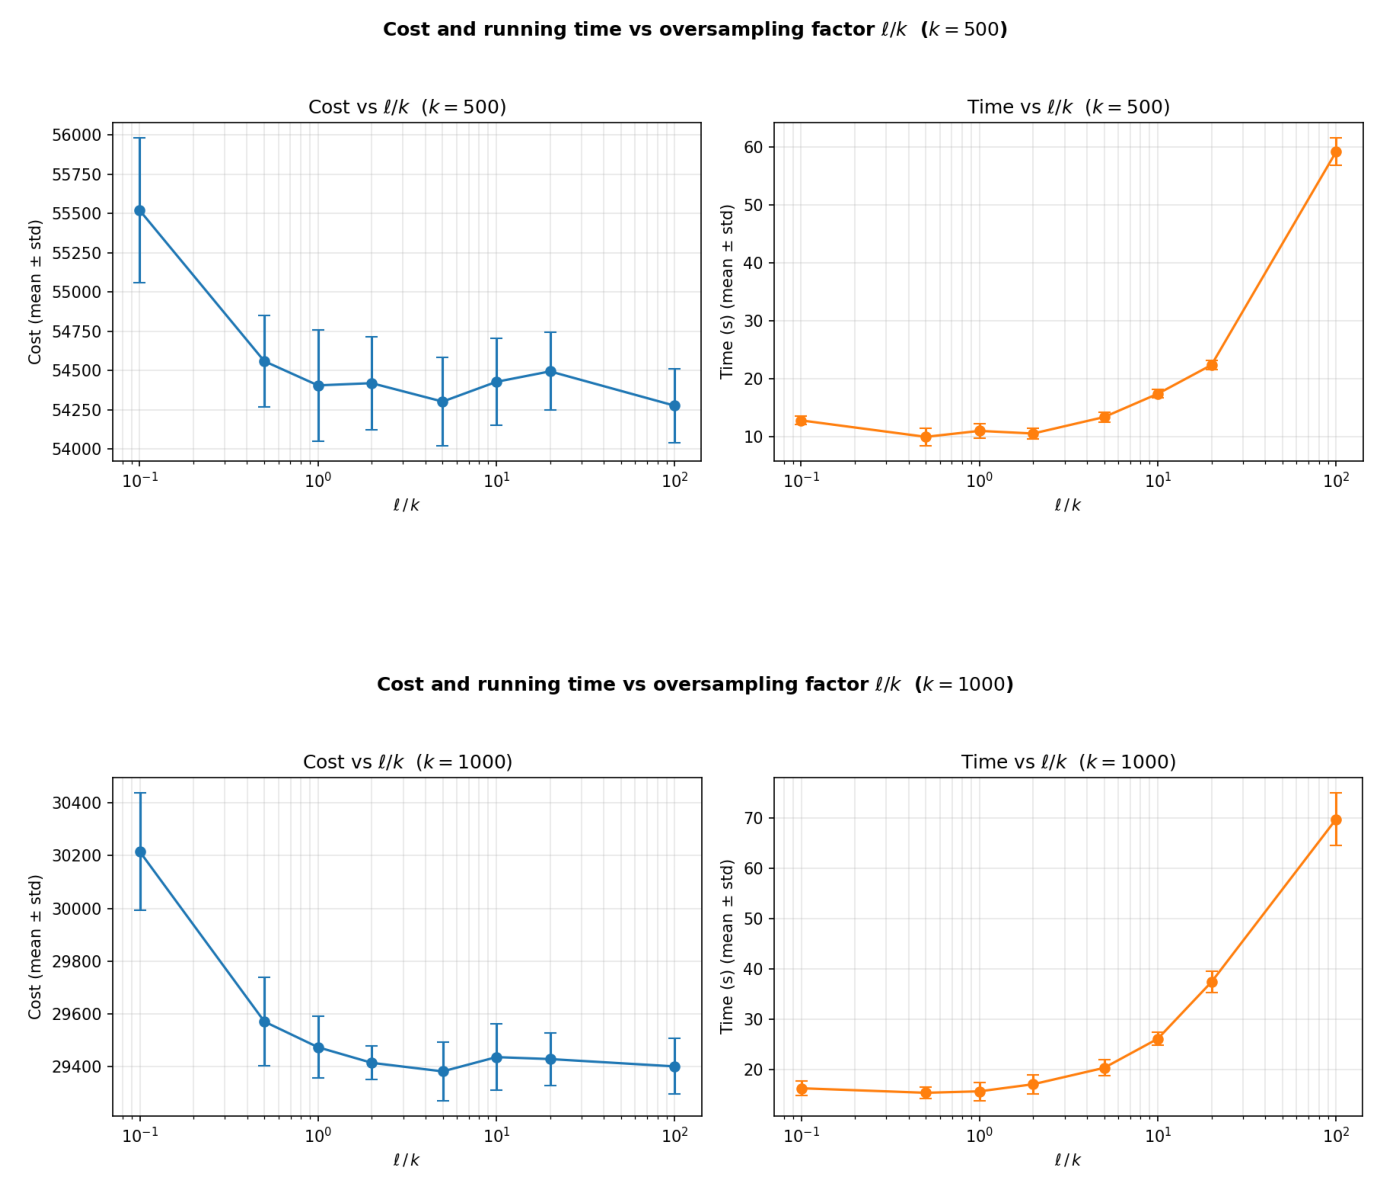

In [3]:
fig1_path = "/home/ubuntu/Project/libero_development/notebooks/figures/l_sweep_k500.png"
fig2_path = "/home/ubuntu/Project/libero_development/notebooks/figures/l_sweep_k1000.png"

img1 = mpimg.imread(fig1_path)
img2 = mpimg.imread(fig2_path)

fig, axes = plt.subplots(2, 1, figsize=(14, 14))

axes[0].imshow(img1)
axes[0].axis("off")

axes[1].imshow(img2)
axes[1].axis("off")

plt.tight_layout()
plt.show()

From the figures we see that the cost monotonically decreases with higher values of $\ell/k$, and that's reasonable since a larger pool covers the data better and leaves the final reclustering room to select the $k$ best representatives rather than being forced to keep every candidate. This is more visible in the cost curves: the final cost drops sharply from $\ell/k = 0.1$ and then flattens out beyond $\ell/k \approx 1$, where the pool is already large enough to almost surely contain a good $k$-subset and extra oversampling is no longer needed.

The running time, unlike the cost, is not monotonic in $\ell/k$: it is highest at $\ell/k = 0.1$ (dominated by the $3\times$ larger round count from the adaptive rule), dips to a minimum around $\ell/k \approx 0.5$–$1$, where $r$ is fixed at $5$ and the extra sampled points are cheap relative to the per-round distributed pass, and then climbs steadily from $\ell/k \geq 5$ onward — by $\ell/k = 100$ it is roughly $5$–$6\times$ the minimum. This growth is not driven by Lloyd's: at large $\ell/k$ the candidate pool is already so rich that the seeding alone nearly matches the final cost ($\text{cost\_seed} \approx \text{cost\_final}$), and Lloyd's converges in a single iteration. The extra time instead comes entirely from the initialization step itself — collecting more sampled points per round and running the client-side weighted k-means++ reclustering over a much larger pool. In other words, past $\ell/k \approx 1$–$2$ we are paying an increasing, accelerating time cost for centers that Lloyd's would have reached anyway, with no corresponding gain in final cost.


By changing the number of rounds $r$, k-means‖ instead interpolates between a purely random initialization of k-means and the biased sequential initialization of k-means++. When $r = 0$, all of the points are sampled uniformly at random, simulating Random initialization; when $\ell=1$ and $r = k$, the algorithm updates the sampling probability after every single point, simulating k-means++.

The next figure shows the results on a 10% sample of KDDCup1999, with varying values of $k$.


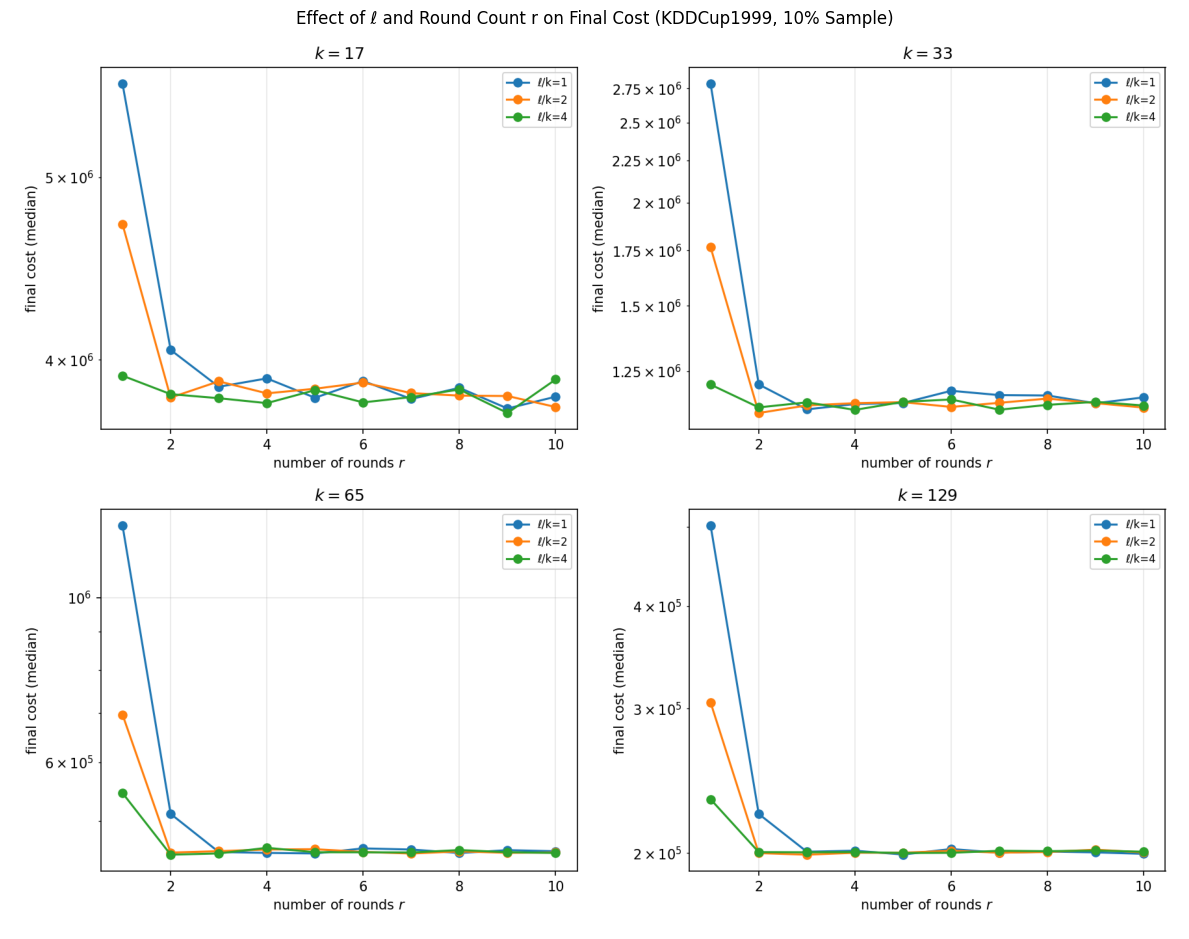

In [4]:
fig1_path = "/home/ubuntu/Project/libero_development/notebooks/figures/fig51_cost_vs_rounds.png"

img1 = mpimg.imread(fig1_path)

fig, axes = plt.subplots(1, 1, figsize=(12, 16))

axes.imshow(img1)
axes.axis("off")
axes.set_title("Effect of ℓ and Round Count r on Final Cost (KDDCup1999, 10% Sample)")


plt.tight_layout()
plt.show()

**Observations**

Across all four panels, the final cost falls off sharply between the first and second round of initialization and then settles onto a flat, stable plateau through round ten, with only minor run-to-run noise. At a single round the three oversampling settings are clearly ordered — larger $\ell/k$ gives a lower cost, since a bigger candidate pool per round yields a better set of points to recluster — but this separation vanishes almost immediately: by round two, the $\ell/k \in \{1,2,4\}$ curves converge and stay indistinguishable for the rest of the sweep. This is expected, since $\ell/k \in \{1,2,4\}$ already gives $\ell \geq k$ candidates in expectation per round, so a single round is enough to fill the pool. The overall cost level also decreases with $k$ across panels, consistent with more clusters reducing total within-cluster distance.

Our curves converge much faster than in the original figure, but the qualitative trend (higher $\ell/k$ → better at low $r$, then convergence) matches. The absolute cost differs from the paper by 10 orders of magnitude or more (~$10^5$–$10^7$ here vs. ~$10^{10}$–$10^{16}$ reported), but this is consistent with feature scale rather than a discrepancy in the algorithm: with z-scored features (unit variance, ~38 dimensions), the maximum possible cost is bounded by roughly $n \times d \approx 1.9\times10^7$ — matching our range. Reaching $10^{10}$–$10^{16}$ requires per-point squared distances far beyond what unit-variance features can produce, but is easily explained by KDD's raw, unstandardized byte/count features (e.g. `src_bytes`, `count`, which range into the millions). We standardize before clustering; the paper's methodology does not disclose whether it does the same, and the scale gap strongly suggests it does not.


## Grid-search of best architecture

Now we want to find the best combination of number of workers and partitions to reduce the total running time. We compare the running time of k-means‖ (parallel implementation), using different numbers of workers and partitions. We performed a grid search on the values `n_workers={2, 3, 4, 5, 6, 7, 8}` and `n_partitions={16, 32, 64, 128, 256}` over the entire KDDCup1999 dataset.


In [5]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib as mpl

sns.set_palette("tab10")

mpl.rcParams.update({
    # Font
    "font.weight": "bold",
    "font.size": 16,

    # Axes
    "axes.labelweight": "bold",
    "axes.titleweight": "bold",
    "axes.titlesize": 18,
    "axes.labelsize": 18,

    # Tick labels
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,

    # Legend
    "legend.fontsize": 16,
    "legend.title_fontsize": 13,

    # Figure title
    "figure.titleweight": "bold",
    "figure.titlesize": 20,

    # Math text (matches regular font)
    "mathtext.default": "bf",
})

In [6]:
workers_csv_path = "/home/ubuntu/Project/libero_development/results/final_csv/workers_partitions.csv"
df = pd.read_csv(workers_csv_path, usecols=["workers", "partitions", "time"])

df = df.loc[:, ["workers", "partitions", "time"]]# , "k", "l"]]
df["time"] = df["time"] / 60

avg_iters = 10

In [7]:
df_grouped = df.groupby(["workers", "partitions"], as_index=False).agg(
    time_mean=("time", "mean"),
    time_std =("time", "std"))
df_grouped["time_std"] = df_grouped["time_std"] / np.sqrt(avg_iters)
df_grouped.head()

,workers,partitions,time_mean,time_std
0,2,16,4.594229,0.245930
1,2,32,2.355339,0.165675
2,2,64,2.846371,0.139464
3,2,128,2.789636,0.044066
4,2,256,2.874366,0.102688


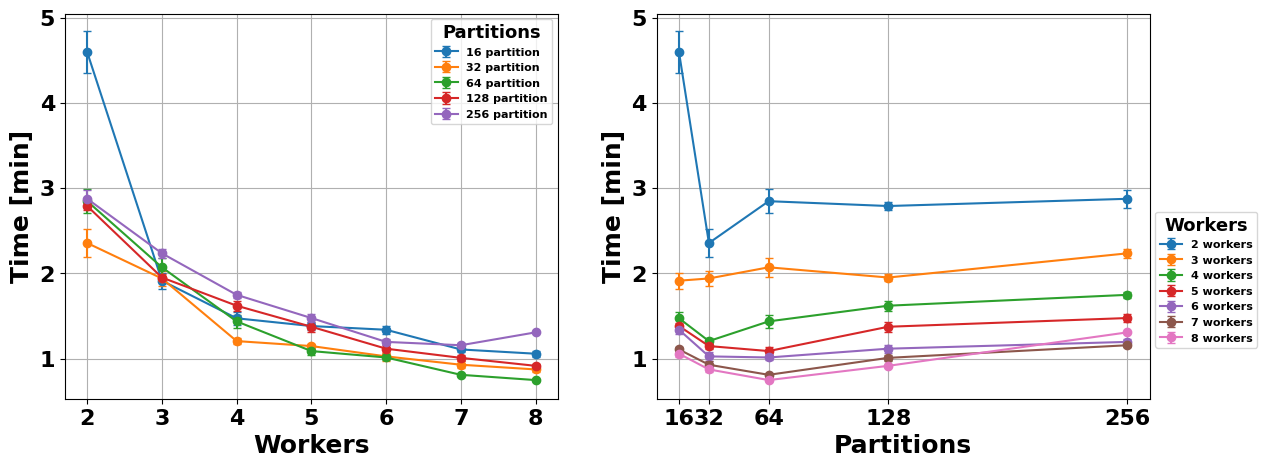

In [8]:
fig, ax = plt.subplots(1, 2, figsize = (14, 5))

for partitions, group in df_grouped.groupby("partitions"):
    ax[0].errorbar(
        group["workers"],
        group["time_mean"],
        yerr=group["time_std"],
        marker="o",
        capsize=3,
        label=f"{partitions} partition"
        )

ax[0].set_xlabel("Workers")
ax[0].set_ylabel("Time [min]")
ax[0].legend(title="Partitions", fontsize=8)
ax[0].grid()


df_grouped = df.groupby(["workers", "partitions"], as_index=False).agg(
    time_mean=("time", "mean"),
    time_std =("time", "std"))
df_grouped["time_std"] = df_grouped["time_std"] / np.sqrt(avg_iters)

for workers, group in df_grouped.groupby("workers"):
    ax[1].errorbar(
        group["partitions"],
        group["time_mean"],
        yerr=group["time_std"],
        marker="o",
        capsize=3,
        label=f"{workers} workers"
    )

ax[1].set_xlabel("Partitions")
ax[1].set_xticks([16, 32, 64, 128, 256])
ax[1].set_ylabel("Time [min]")
ax[1].legend(title="Workers", fontsize=8, bbox_to_anchor=(1, 0.5))
ax[1].grid()

#fig.legend( loc="outside upper right")

From the graph on the left, we notice that the best results are obtained for `n_partitions={32, 64}`, indicating that too many partitions cause a slowdown, probably due to moving data around the cluster and not taking advantage of the computation capabilities. More specifically, with fewer than 4 workers, 32 partitions is the best choice, while for more than 4 workers, 64 is the best choice.
The best absolute results are for 8 workers, but having more workers doesn't necessarily imply less computing time: 7 workers with 256 partitions is slower than 4 workers with 32 partitions, for instance.


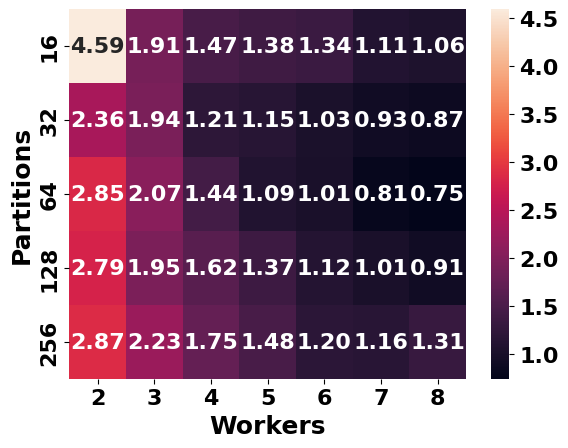

In [9]:
heatmap_data = df_grouped.reset_index().pivot(
    index="partitions",
    columns="workers",
    values="time_mean"
)

sns.heatmap(heatmap_data, annot=True, fmt=".2f", cmap="rocket")

plt.xlabel("Workers")
plt.ylabel("Partitions")
plt.show()

The heatmap shows that the best results are achieved with a high number of workers combined with a moderate number of partitions (32–64), rather than very low (16) or very high (128–256) values.


##  Tuning parameters quality with running time

Following the format of Table 3 in the original paper, we tested k-means‖ with $k \in \{500, 1000\}$ and $\ell \in \{0.1k, 0.5k, k, 2k, 10k\}$, with $r=15$ rounds for the case $\ell=0.1k$, and $r=5$ rounds otherwise: running k-means‖ for five rounds when $\ell=0.1k$ leads it to select fewer than $k$ centers with high probability. Along with k-means‖ we also test Random initialization: for Random, we reuse the same parallel implementation with the number of rounds set to zero ($r=0$), which reduces k-means‖ to picking $k$ points uniformly at random. In the sequential setting we ran Random until convergence, while in the parallel version we bounded the number of iterations to 20.

As in the paper, each value is the **median over 11 random seeds**, to smooth out run-to-run variance.

Table 3 shows the **clustering cost** — the final $k$-means objective after Lloyd's iterations converge. Table 4 shows the **total running time** (initialization + Lloyd's refinement, in minutes), giving a sense of the actual cost of running each configuration in practice.


In [10]:
random_csv = "/home/ubuntu/Project/libero_development/results/final_csv/random_l_su_k_final.csv"
kmeans_csv = "/home/ubuntu/Project/libero_development/results/final_csv/l_su_k_final.csv"


ks = [500, 1000]
ratios = [0.1, 0.5, 1, 2, 10]
ratio_labels = {0.1: "0.1k", 0.5: "0.5k", 1: "k", 2: "2k", 10: "10k"}


def median_by_k(csv_path, value_col):
    df = pd.read_csv(csv_path)
    return df.groupby("k")[value_col].median().to_dict()


def median_by_k_ratio(csv_path, value_col):
    df = pd.read_csv(csv_path)
    return df.groupby(["k", "l_over_k"])[value_col].median().to_dict()


def sigfig(x, n=3):
    if pd.isna(x):
        return "--"
    return f"{x:.{n}g}"


def build_table(value_col, unit_scale=1.0, sig=3):
    random_med = median_by_k(random_csv, value_col)
    kmeans_med = median_by_k_ratio(kmeans_csv, value_col)

    index = [("Random", "")]
    index += [(r"k-means||, l=", ratio_labels[r]) for r in ratios]

    rows = []
    rows.append([sigfig(random_med.get(k, np.nan) * unit_scale, sig) for k in ks])
    for r in ratios:
        rows.append([sigfig(kmeans_med.get((k, r), np.nan) * unit_scale, sig) for k in ks])

    return pd.DataFrame(rows, index=pd.MultiIndex.from_tuples(index), columns=[f"k={k}" for k in ks])


table3_cost = build_table("final_cost")
table4_time = build_table("time", unit_scale=1 / 60)

print("Table 3 - clustering cost")
display(table3_cost)

print("Table 4 - running time (minutes)")
display(table4_time)


Table 3 - clustering cost


k=500    k=1000
Random              3.63e+07  2.48e+07
k-means||, l= 0.1k  5.85e+05  3.14e+05
              0.5k  5.76e+05  3.09e+05
              k      5.7e+05  3.08e+05
              2k    5.71e+05  3.07e+05
              10k   5.72e+05  3.08e+05

Table 4 - running time (minutes)


k=500 k=1000
Random              0.831    1.2
k-means||, l= 0.1k  0.829   1.11
              0.5k  0.719   1.06
              k     0.752   1.09
              2k     0.87   1.26
              10k    1.32   2.28

The results confirm the paper's headline finding: k-means‖ crushes Random initialization by nearly two orders of magnitude in clustering cost (e.g. ~3.6×10⁷ vs ~5.7×10⁵ for k=500), even though both eventually run the same Lloyd's refinement, a much better starting point really does matter.

Where our results diverge a bit from the paper is in the effect of ℓ. The paper reports cost improving monotonically as ℓ grows, up to ℓ=10k. In our runs, the cost drops sharply from ℓ=0.1k to ℓ=k, but then essentially **plateaus**, where the differences between ℓ=k, ℓ=2k and ℓ=10k are within noise across seeds, with no clear further improvement. This suggests that, at least for our setup, ℓ=k already captures most of the achievable initialization quality, and oversampling further gives diminishing returns.

That plateau matters because the running time tells the opposite story: time grows with ℓ, and the jump to ℓ=10k is steep (nearly 1.5–2× slower than ℓ=k). So beyond ℓ=k we're paying significantly more time for essentially no gain in cost — a trade-off worth of notice, since blindly picking the largest ℓ would be the wrong thing here.

At the end we compare the total running time for the kmeans parallel algorithm for the 10% dataset of KDD and the full dataset. We report the computing time for the 10% the dataset, over the running time for the entire one.

In [11]:
l_over_k_10percent_path = "/home/ubuntu/Project/libero_development/results/final_csv/l_sweep_10pct_full.csv"

df10 = pd.read_csv(l_over_k_10percent_path, usecols=["k", "l_over_k", "time_total"])

df10.rename(columns={"time_total": "time"}, inplace=True)
df10 = df10[df10["l_over_k"].isin(ratios)]

df10_grouped = df10.groupby(["k","l_over_k"]).median()

In [12]:
l_over_k_full_path = "/home/ubuntu/Project/libero_development/results/final_csv/l_su_k_final.csv"

df = pd.read_csv(l_over_k_full_path, usecols=["k", "l_over_k", "time"])

df_grouped = df.groupby(["k","l_over_k"]).median()

In [13]:
results = np.round(df10_grouped / df_grouped, decimals=2)
results.rename(columns={"time": "time_10 / time_full"})

time_10 / time_full
k    l_over_k                     
500  0.1                      0.26
     0.5                      0.23
     1.0                      0.24
     2.0                      0.20
     10.0                     0.22
1000 0.1                      0.24
     0.5                      0.24
     1.0                      0.24
     2.0                      0.22
     10.0                     0.19

The running time doesn't scale proportionally to the dataset size: for the smaller dataset it is 20% or larger than the time needed for the full dataset (in all cases except `k=1000` and `l/k=10`). Scaling from the 10% sample to the full dataset (10× more points) only increases running time by roughly $4$–$5\times$. This result is expected as the running time accounts for both pure computing time and the time needed to move partions, read the dataset and other operations. This suggests a substantial part of the per-round cost is fixed communication/scheduling overhead rather than actual computation, which amortizes better as the dataset grows.


## Conclusions